# 🏪 Superstore Sales Analysis

## Business Objective
Analyze the Superstore dataset to find revenue drivers,
profitability patterns, and areas for improvement.

**Dataset:** 9,694 orders | 21 columns | 2014-2017
**Tools:** Python, Pandas, Matplotlib, Seaborn
**Author:** Yashodha





In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
print('Data loaded!')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')


Saving Sample - Superstore.csv to Sample - Superstore.csv
Data loaded!
Rows: 9994, Columns: 22


## Dataset Overview
Let’s look at the key numbers first.


In [2]:
# Business overview
print('=' * 50)
print('SUPERSTORE OVERVIEW')
print('=' * 50)
print(f"Total Orders:    {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"Total Revenue:   ${df['Sales'].sum():,.2f}")
print(f"Total Profit:    ${df['Profit'].sum():,.2f}")
print(f"Profit Margin:   {df['Profit'].sum()/df['Sales'].sum()*100:.1f}%")
print(f"Date Range:      {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print('=' * 50)


SUPERSTORE OVERVIEW
Total Orders:    5,009
Total Customers: 793
Total Revenue:   $2,297,200.86
Total Profit:    $286,397.02
Profit Margin:   12.5%
Date Range:      2014-01-03 to 2017-12-30


## 1. Revenue by Category
Which product category brings the most money?


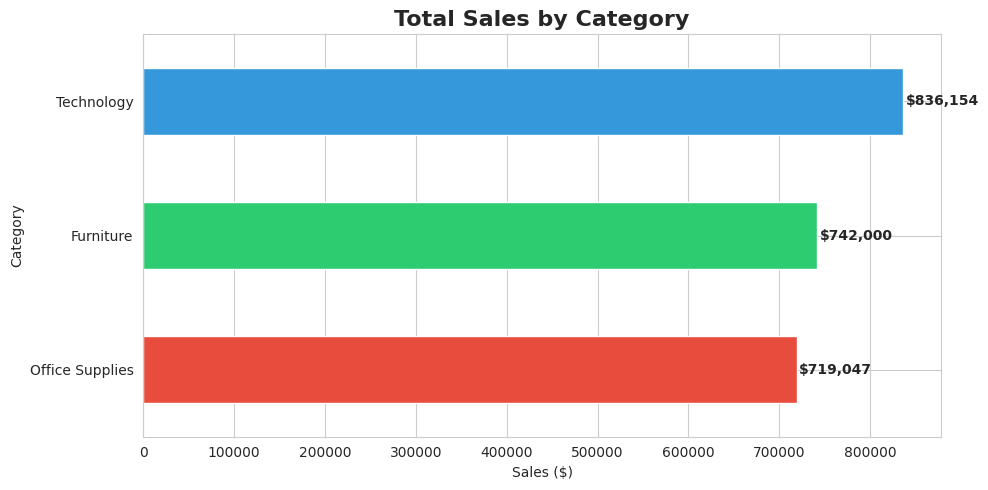

In [3]:
cat = df.groupby('Category')['Sales'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
cat.plot(kind='barh', color=['#e74c3c','#2ecc71','#3498db'], ax=ax)
ax.set_title('Total Sales by Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Sales ($)')

# Add value labels
for i, v in enumerate(cat):
    ax.text(v + 3000, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


### 💡 Insight
Technology has the highest total sales, followed by Furniture
and Office Supplies. Technology products tend to be higher-priced
items like phones and machines


## 2. Sub-Categories Losing Money
Are there products that actually lose money?


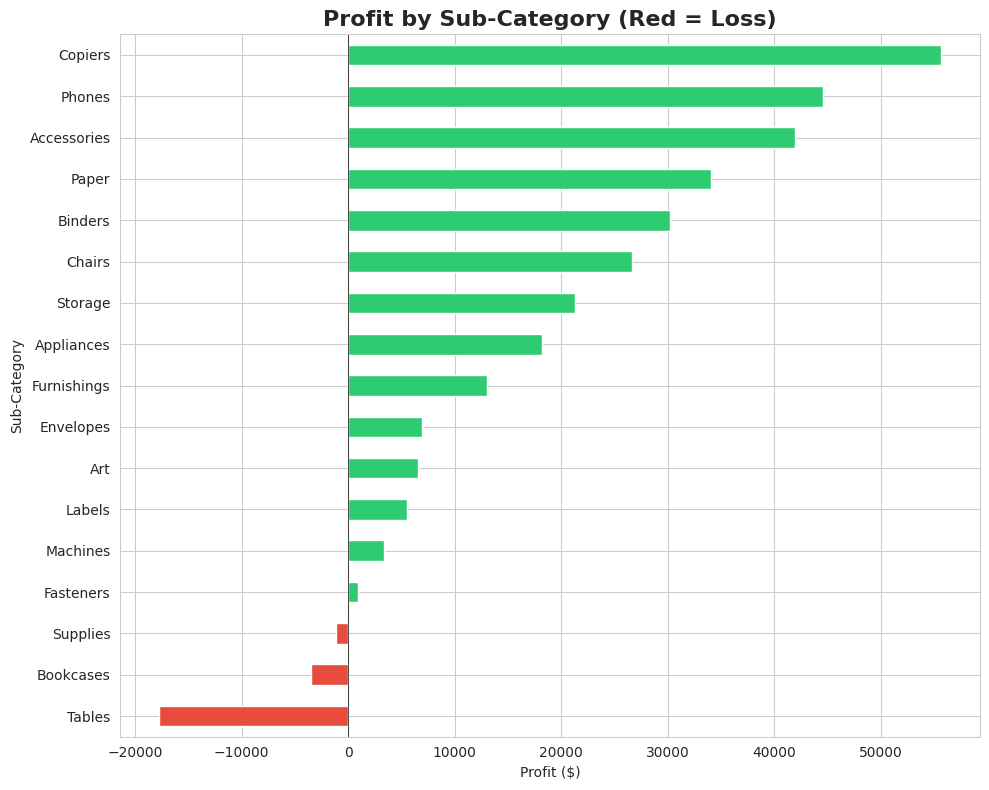


Sub-categories LOSING money:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


In [5]:

sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sub]

fig, ax = plt.subplots(figsize=(10, 8))
sub.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Profit by Sub-Category (Red = Loss)', fontsize=16, fontweight='bold')
ax.set_xlabel('Profit ($)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Show losing sub-categories
print('\nSub-categories LOSING money:')
losers = df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(losers[losers < 0])


### 💡 Insight
**Tables, Bookcases, and Supplies** are losing money.
These sub-categories generate revenue but the costs and
discounts eat into the profit.

**Recommendation:** Review pricing and discount strategy
for these three sub-categories.


## 3. Monthly Sales Trend
How are sales changing over time? Any seasonal patterns?



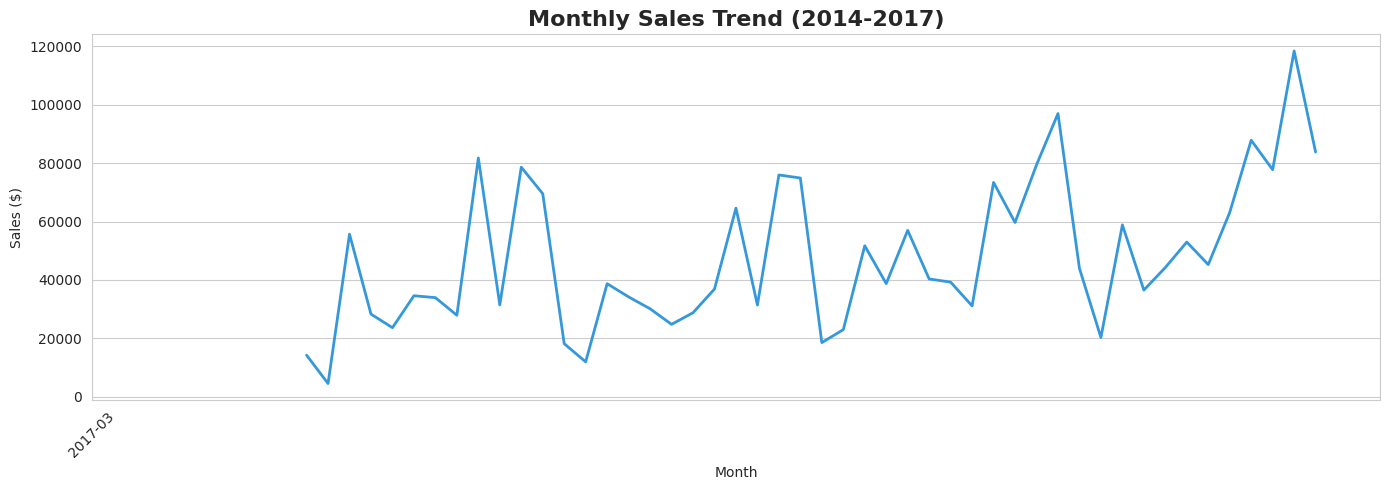


Yearly Sales:
Year
2014    484247.50
2015    470532.51
2016    609205.60
2017    733215.26
Name: Sales, dtype: float64


In [6]:
# Line chart: Monthly sales trend
monthly = df.groupby(df['Order Date'].dt.strftime('%Y-%m'))['Sales'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(kind='line', color='#3498db', linewidth=2, ax=ax)
ax.set_title('Monthly Sales Trend (2014-2017)', fontsize=16, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Month')
ax.set_xticks(ax.get_xticks()[::6])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nYearly Sales:')
print(df.groupby('Year')['Sales'].sum().round(2))


### 💡 Insight
Sales are growing year over year. There are clear seasonal
spikes in **November-December** (holiday season) and dips
in **January-February**.

**Recommendation:** Prepare extra inventory for Q4 holiday
rush. Plan promotions during slow months (Q1).


## 4. Does Discounting Help or Hurt?
Let’s see if higher discounts lead to more profit or more losses


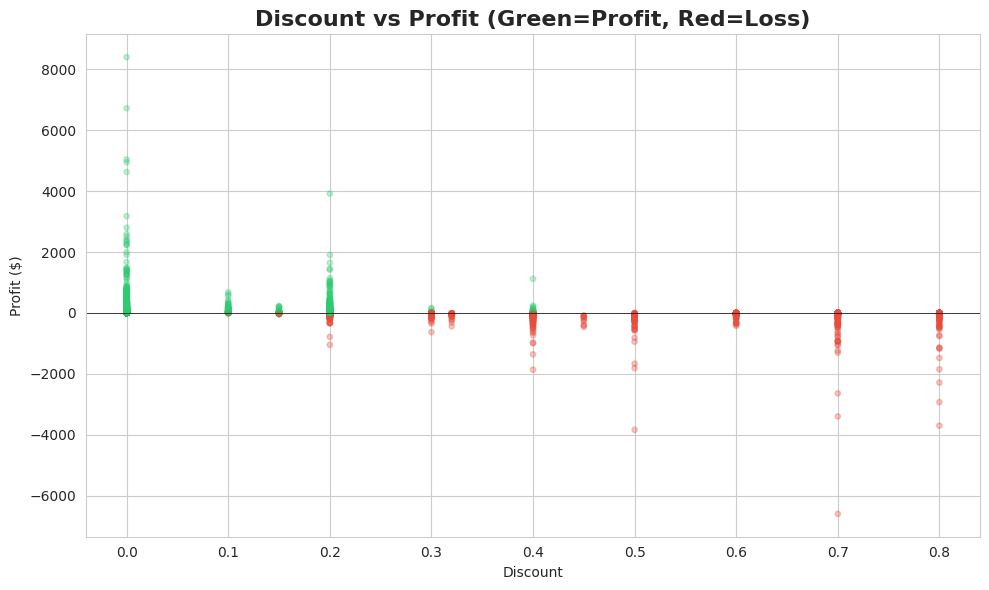

In [7]:
# Scatter plot: Discount vs Profit
fig, ax = plt.subplots(figsize=(10, 6))
colors = df['Profit'].apply(lambda x: '#2ecc71' if x > 0 else '#e74c3c')
ax.scatter(df['Discount'], df['Profit'], c=colors, alpha=0.3, s=15)
ax.set_title('Discount vs Profit (Green=Profit, Red=Loss)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


### 💡 Insight
There is a clear pattern: **higher discounts lead to more
losses**. Orders with discounts above 20% almost always
lose money.

**Recommendation:** Cap maximum discount at 20%. Any
discount above this threshold destroys profit.



## 5. Regional Performance
Which region performs the best?


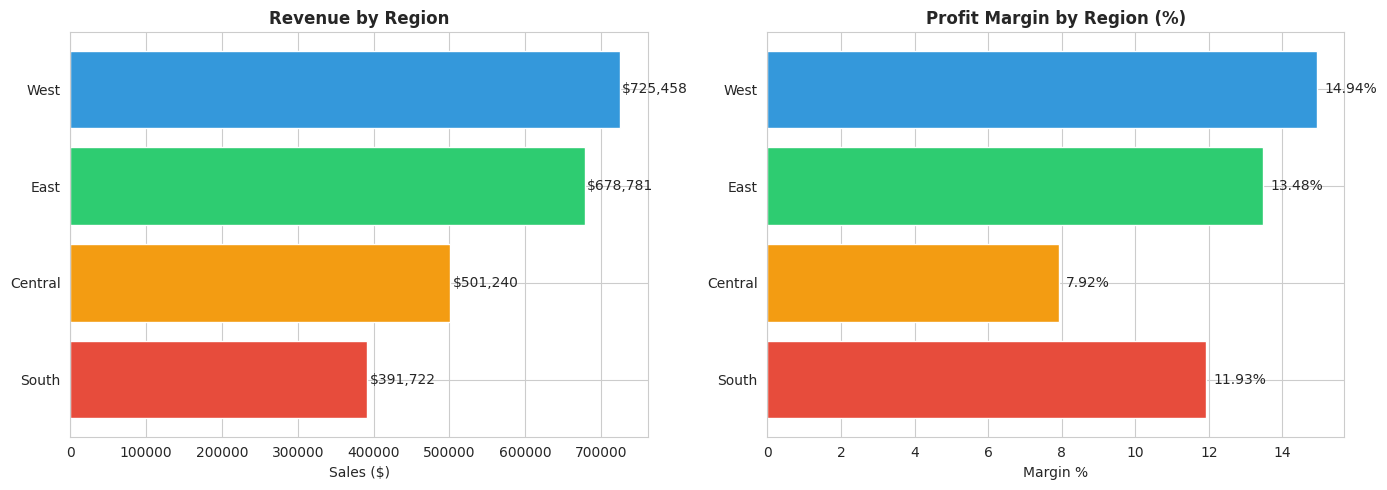

 Region  Orders     Sales    Profit  Margin %
  South     822 391721.90  46749.43     11.93
Central    1175 501239.89  39706.36      7.92
   East    1401 678781.24  91522.78     13.48
   West    1611 725457.82 108418.45     14.94


In [8]:

region = df.groupby('Region').agg({
    'Order ID': 'nunique',
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2).reset_index()
region.columns = ['Region', 'Orders', 'Sales', 'Profit']
region['Margin %'] = round(region['Profit'] / region['Sales'] * 100, 2)
region = region.sort_values('Sales', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c','#f39c12','#2ecc71','#3498db']
axes[0].barh(region['Region'], region['Sales'], color=colors)
axes[0].set_title('Revenue by Region', fontweight='bold')
axes[0].set_xlabel('Sales ($)')
for i, v in enumerate(region['Sales']):
    axes[0].text(v + 3000, i, f'${v:,.0f}', va='center')


axes[1].barh(region['Region'], region['Margin %'], color=colors)
axes[1].set_title('Profit Margin by Region (%)', fontweight='bold')
axes[1].set_xlabel('Margin %')
for i, v in enumerate(region['Margin %']):
    axes[1].text(v + 0.2, i, f'{v}%', va='center')

plt.tight_layout()
plt.show()

print(region.to_string(index=False))


### 💡 Insight
**West** region leads in both revenue and profit.
**Central** region has the lowest margin despite decent
revenue — likely due to higher discounting.

**Recommendation:** Audit Central region’s discount policies.


## 6. Conclusions & Recommendations

### Key Findings:
1. **Technology** drives the most revenue
2. **Tables, Bookcases, Supplies** are losing money
3. **Discounts above 20%** destroy profitability
4. **Nov-Dec** is peak season (holiday effect)
5. **West region** is the top performer
6. **Central region** needs discount policy review

### Recommendations:
1. Cap all discounts at 20% maximum
2. Review pricing for Tables, Bookcases, Supplies
3. Audit Central region discount approvals
4. Increase Q4 inventory for holiday rush
5. Plan promotions during slow Q1 months

---
*Analysis by Yashodha | Tools: Python, Pandas, Matplotlib, Seaborn*
